# 🎭 swaFaceMo - Face Swap Pipeline Testing
### Step-by-step testing on RTX 2050 (4GB VRAM)
---

## Cell 1: Environment Check & GPU Verification

In [1]:
import torch
import cv2
import numpy as np
from PIL import Image
import os, sys

print('='*50)
print('swaFaceMo - Environment Check')
print('='*50)
print(f'PyTorch: {torch.__version__}')
print(f'CUDA Available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM: {total:.1f} GB')
    print(f'CUDA Version: {torch.version.cuda}')
print(f'OpenCV: {cv2.__version__}')
print('✅ Environment OK!')

swaFaceMo - Environment Check
PyTorch: 2.0.1+cu118
CUDA Available: True
GPU: NVIDIA GeForce RTX 2050
VRAM: 4.3 GB
CUDA Version: 11.8
OpenCV: 4.10.0
✅ Environment OK!


## Cell 2: Load InsightFace (Face Detector + Embedder)

In [2]:
import insightface
from insightface.app import FaceAnalysis

# Initialize face analyzer
# det_size=(320,320) is faster, (640,640) is more accurate
face_analyzer = FaceAnalysis(
    name='buffalo_l',          # Best accuracy model
    providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
)
face_analyzer.prepare(ctx_id=0, det_size=(640, 640))
print('✅ InsightFace FaceAnalysis loaded!')

# Test on a sample image
# Create a test image (replace with real path)
test_img = np.zeros((512, 512, 3), dtype=np.uint8) + 128
faces = face_analyzer.get(test_img)
print(f'Faces detected in test image: {len(faces)}')
print('InsightFace ready! buffalo_l model provides: age, gender, embedding, keypoints, bbox')

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\jadha/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\jadha/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\jadha/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\jadha/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\jadha/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.

## Cell 3: Load Face Swapper Model (inswapper_128)

In [3]:
import insightface
import onnxruntime as ort

# Check ONNX Runtime providers
print('Available ONNX Providers:', ort.get_available_providers())

# Model path - inswapper_128.onnx must be downloaded
# Download from: https://github.com/deepinsight/insightface
# SWAPPER_MODEL_PATH = r'D:\1Npro\swaFaceMo\models\inswapper_128.onnx'
SWAPPER_MODEL_PATH = r"D:\1Npro\models\inswapper_128.onnx"

if not os.path.exists(SWAPPER_MODEL_PATH):
    print('⚠️  inswapper_128.onnx NOT FOUND!')
    print('Download it from: https://huggingface.co/deepinsight/inswapper/resolve/main/inswapper_128.onnx')
    print('Place at:', SWAPPER_MODEL_PATH)
else:
    face_swapper = insightface.model_zoo.get_model(
        SWAPPER_MODEL_PATH,
        providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
    )
    print('✅ Face Swapper (inswapper_128) loaded!')
    print('Model input size: 128x128 (upscaled after swap)')

Available ONNX Providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
inswapper-shape: [1, 3, 128, 128]
✅ Face Swapper (inswapper_128) loaded!
Model input size: 128x128 (upscaled after swap)


In [4]:
import torch
import torchvision
print(torch.__version__)
print(torchvision.__version__)

2.0.1+cu118
0.15.2+cu118


In [5]:
# pip uninstall torch torchvision torchaudio -y  
# pip install torch==2.0.1+cu118 torchvision==0.15.2+cu118 torchaudio==2.0.2+cu118 --extra-index-url https://download.pytorch.org/whl/cu118

In [6]:
# pip uninstall gfpgan basicsr
# pip install git+https://github.com/TencentARC/GFPGAN.git
# pip install git+https://github.com/xinntao/BasicSR.git

In [7]:
import torchvision.transforms.functional as F
print("Imported successfully!")  # Agar yeh chal gaya to fix ho gaya

Imported successfully!


In [8]:
import torchvision.transforms.functional_tensor as FT
print("functional_tensor imported successfully!")

from gfpgan import GFPGANer
print("GFPGAN imported successfully!")

functional_tensor imported successfully!


C:\Users\jadha\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\transforms\functional_tensor.py:5: UserWarning: The torchvision.transforms.functional_tensor module is deprecated in 0.15 and will be **removed in 0.17**. Please don't rely on it. You probably just need to use APIs in torchvision.transforms.functional or in torchvision.transforms.v2.functional.
  warnings.warn(


GFPGAN imported successfully!


## Cell 4: Load GFPGAN Face Enhancer (Quality Boost)

In [9]:
import torch
from gfpgan import GFPGANer

# GFPGAN v1.4 - best quality
# GFPGAN_MODEL_PATH = r'D:\1Npro\models\GFPGANv1.4.pth'
GFPGAN_MODEL_PATH = r"D:\1Npro\models\GFPGANv1.4.pth"

if not os.path.exists(GFPGAN_MODEL_PATH):
    print('⚠️  GFPGANv1.4.pth NOT FOUND!')
    print('Download: https://github.com/TencentARC/GFPGAN/releases/download/v1.3.4/GFPGANv1.4.pth')
    print('Place at:', GFPGAN_MODEL_PATH)
else:
    # upscale=1 to keep same size, use RealESRGAN for upscaling separately
    face_enhancer = GFPGANer(
        model_path=GFPGAN_MODEL_PATH,
        upscale=1,
        arch='clean',
        channel_multiplier=2,
        bg_upsampler=None  # We'll handle upscaling separately
    )
    print('✅ GFPGAN v1.4 loaded for face enhancement!')
    
    # Check VRAM after loading
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated(0) / 1e9
        print(f'VRAM used after GFPGAN load: {allocated:.2f} GB')

C:\Users\jadha\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\jadha\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Downloading: "https://github.com/xinntao/facexlib/releases/download/v0.1.0/detection_Resnet50_Final.pth" to D:\1Npro\files_feb_22_claude\gfpgan\weights\detection_Resnet50_Final.pth



100%|███████████████████████████████████████████████████████████████████████████████| 104M/104M [01:21<00:00, 1.34MB/s]


Downloading: "https://github.com/xinntao/facexlib/releases/download/v0.2.2/parsing_parsenet.pth" to D:\1Npro\files_feb_22_claude\gfpgan\weights\parsing_parsenet.pth



100%|█████████████████████████████████████████████████████████████████████████████| 81.4M/81.4M [00:38<00:00, 2.21MB/s]


✅ GFPGAN v1.4 loaded for face enhancement!
VRAM used after GFPGAN load: 0.55 GB


## Cell 5: Load RealESRGAN Upscaler (720p Quality)

In [10]:
from basicsr.archs.rrdbnet_arch import RRDBNet
from realesrgan import RealESRGANer

REALESRGAN_PATH = r'D:\1Npro\models\RealESRGAN_x4plus.pth'

if os.path.exists(REALESRGAN_PATH):
    model = RRDBNet(
        num_in_ch=3, num_out_ch=3,
        num_feat=64, num_block=23, num_grow_ch=32, scale=4
    )
    upsampler = RealESRGANer(
        scale=4,
        model_path=REALESRGAN_PATH,
        model=model,
        tile=256,        # Tile processing to fit in 4GB VRAM
        tile_pad=10,
        pre_pad=0,
        half=True        # FP16 for RTX 2050 memory efficiency
    )
    print('✅ RealESRGAN x4plus loaded with tile=256 for 4GB VRAM!')
    print('Tile processing: handles large images within VRAM limits')
else:
    print(f'⚠️  RealESRGAN not found at {REALESRGAN_PATH}')
    print('Already downloaded at D:\\1Npro\\models\\RealESRGAN_x4plus.pth ✅')

✅ RealESRGAN x4plus loaded with tile=256 for 4GB VRAM!
Tile processing: handles large images within VRAM limits


## Cell 6: Core Image Face Swap Function

In [11]:
def swap_faces_image(source_img_path, target_img_path, enhance=True, upscale_to_720=False):
    """
    Swap face from source into target image.
    source: the face you want to USE
    target: the image you want to PUT the face INTO
    """
    import time
    start = time.time()
    
    # Load images
    source_img = cv2.imread(source_img_path)
    target_img = cv2.imread(target_img_path)
    
    if source_img is None:
        raise ValueError(f'Cannot load source: {source_img_path}')
    if target_img is None:
        raise ValueError(f'Cannot load target: {target_img_path}')
    
    print(f'Source size: {source_img.shape[:2]}')
    print(f'Target size: {target_img.shape[:2]}')
    
    # Step 1: Detect faces
    source_faces = face_analyzer.get(source_img)
    target_faces = face_analyzer.get(target_img)
    
    if len(source_faces) == 0:
        raise ValueError('❌ No face detected in SOURCE image!')
    if len(target_faces) == 0:
        raise ValueError('❌ No face detected in TARGET image!')
    
    print(f'Source faces found: {len(source_faces)}')
    print(f'Target faces found: {len(target_faces)}')
    
    # Use the first (largest) face from source
    source_face = sorted(source_faces, key=lambda x: x.bbox[2]-x.bbox[0], reverse=True)[0]
    
    # Step 2: Perform face swap on ALL target faces
    result_img = target_img.copy()
    for target_face in target_faces:
        result_img = face_swapper.get(result_img, target_face, source_face, paste_back=True)
    
    print(f'⏱️  Face swap done in {time.time()-start:.2f}s')
    
    # Step 3: GFPGAN Enhancement
    if enhance:
        t = time.time()
        _, _, result_img = face_enhancer.enhance(
            result_img, 
            has_aligned=False, 
            only_center_face=False, 
            paste_back=True
        )
        print(f'⏱️  GFPGAN enhancement done in {time.time()-t:.2f}s')
    
    # Step 4: Optional 720p upscaling
    if upscale_to_720:
        h, w = result_img.shape[:2]
        if h < 720:
            t = time.time()
            result_img, _ = upsampler.enhance(result_img, outscale=720/h)
            print(f'⏱️  Upscaling done in {time.time()-t:.2f}s')
    
    total = time.time() - start
    print(f'\n✅ Total time: {total:.2f}s')
    print(f'Output size: {result_img.shape[:2]}')
    return result_img

print('✅ swap_faces_image() function ready!')

✅ swap_faces_image() function ready!


## Cell 7: Test Image Face Swap (Replace paths with your images)

Source size: (248, 256)
Target size: (515, 404)


C:\Users\jadha\AppData\Local\Programs\Python\Python310\lib\site-packages\insightface\utils\transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4


Source faces found: 1
Target faces found: 1
⏱️  Face swap done in 1.72s
⏱️  GFPGAN enhancement done in 0.76s
	Tile 1/6
	Tile 2/6
	Tile 3/6
	Tile 4/6
	Tile 5/6
	Tile 6/6
⏱️  Upscaling done in 2.89s

✅ Total time: 5.37s
Output size: (720, 564)
✅ Saved to: D:\1Npro\files_feb_22_claude\op\output_result.jpg


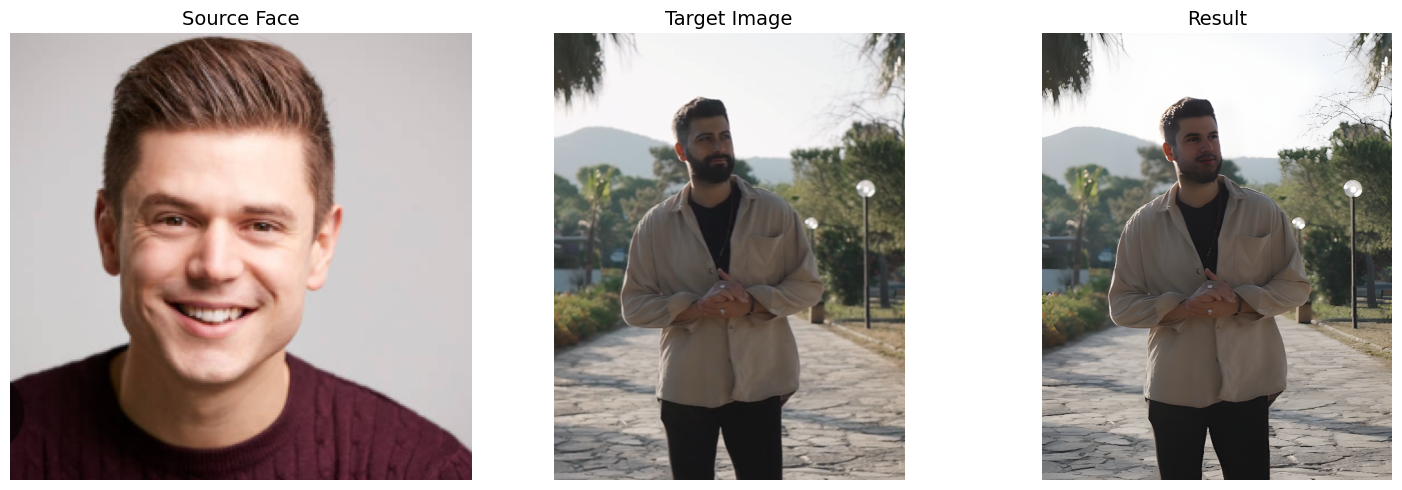

In [15]:
from IPython.display import display
import matplotlib.pyplot as plt

# ⚠️ REPLACE THESE WITH YOUR ACTUAL IMAGE PATHS
SOURCE_FACE = r"D:\1Npro\files_feb_22_claude\test_images\t2.png"
TARGET_IMAGE = r"D:\1Npro\files_feb_22_claude\test_images\target1.png"
OUTPUT_PATH = r'D:\1Npro\files_feb_22_claude\op\output_result.jpg'

# Create test_images folder
os.makedirs(r"D:\1Npro\files_feb_22_claude\test_images", exist_ok=True)

if os.path.exists(SOURCE_FACE) and os.path.exists(TARGET_IMAGE):
    result = swap_faces_image(
        SOURCE_FACE, 
        TARGET_IMAGE,
        enhance=True,          # GFPGAN quality boost
        upscale_to_720=True    # Upscale to 720p
    )
    cv2.imwrite(OUTPUT_PATH, result)
    print(f'✅ Saved to: {OUTPUT_PATH}')
    
    # Display
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(cv2.cvtColor(cv2.imread(SOURCE_FACE), cv2.COLOR_BGR2RGB))
    axes[0].set_title('Source Face', fontsize=14)
    axes[1].imshow(cv2.cvtColor(cv2.imread(TARGET_IMAGE), cv2.COLOR_BGR2RGB))
    axes[1].set_title('Target Image', fontsize=14)
    axes[2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    axes[2].set_title('Result', fontsize=14)
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.savefig("D:/1Npro/files_feb_22_claude/test_images/comparison.jpg", dpi=150)
    plt.show()
else:
    print('⚠️  Test images not found! Add your images to D:\\1Npro\\swaFaceMo\\test_images\\')
    print('   source_face.jpg  = The face you want to use')
    print('   target_image.jpg = The image to swap into')

## Cell 8: Video Face Swap Function (Frame-by-Frame)

In [16]:
import cv2
import numpy as np
from tqdm.notebook import tqdm
import subprocess

def swap_faces_video(
    source_img_path,
    target_video_path,
    output_path,
    enhance=True,
    enhance_every_n=3,    # Enhance every 3rd frame to save time
    max_frames=None,      # None = full video, or limit for testing
    target_height=720
):
    """
    Video face swap optimized for RTX 2050 4GB VRAM
    enhance_every_n: GFPGAN is expensive, run every N frames for speed
    """
    import time
    
    # Load source face once
    source_img = cv2.imread(source_img_path)
    source_faces = face_analyzer.get(source_img)
    if len(source_faces) == 0:
        raise ValueError('No face in source image!')
    source_face = sorted(source_faces, key=lambda x: x.bbox[2]-x.bbox[0], reverse=True)[0]
    print(f'✅ Source face loaded and cached')
    
    # Open video
    cap = cv2.VideoCapture(target_video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    orig_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    orig_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    if max_frames:
        total_frames = min(total_frames, max_frames)
    
    # Scale to target height maintaining aspect ratio
    scale = target_height / orig_h
    out_w = int(orig_w * scale)
    out_h = target_height
    # Make even numbers
    out_w = out_w if out_w % 2 == 0 else out_w - 1
    
    duration = total_frames / fps
    print(f'Video: {orig_w}x{orig_h} @ {fps:.1f}fps')
    print(f'Output: {out_w}x{out_h} | Total frames: {total_frames} | Duration: {duration:.1f}s')
    
    # Write to temp file first (no audio), then merge audio
    temp_output = output_path.replace('.mp4', '_noaudio.mp4')
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(temp_output, fourcc, fps, (out_w, out_h))
    
    frame_idx = 0
    times = []
    
    with tqdm(total=total_frames, desc='Processing frames') as pbar:
        while frame_idx < total_frames:
            ret, frame = cap.read()
            if not ret:
                break
            
            t = time.time()
            
            # Resize frame
            frame = cv2.resize(frame, (out_w, out_h))
            
            # Detect faces in this frame
            target_faces = face_analyzer.get(frame)
            
            if len(target_faces) > 0:
                # Swap faces
                for target_face in target_faces:
                    frame = face_swapper.get(frame, target_face, source_face, paste_back=True)
                
                # Enhance every N frames
                if enhance and frame_idx % enhance_every_n == 0:
                    _, _, frame = face_enhancer.enhance(
                        frame, has_aligned=False, 
                        only_center_face=False, paste_back=True
                    )
            
            writer.write(frame)
            times.append(time.time() - t)
            
            frame_idx += 1
            
            if frame_idx % 10 == 0:
                avg_t = np.mean(times[-10:])
                eta = avg_t * (total_frames - frame_idx)
                pbar.set_postfix({'fps': f'{1/avg_t:.1f}', 'ETA': f'{eta:.0f}s'})
            pbar.update(1)
    
    cap.release()
    writer.release()
    
    # Merge audio from original
    print('\n🎵 Merging original audio...')
    try:
        cmd = [
            'ffmpeg', '-y',
            '-i', temp_output,
            '-i', target_video_path,
            '-map', '0:v:0',
            '-map', '1:a:0',
            '-c:v', 'libx264',
            '-crf', '18',        # High quality
            '-preset', 'slow',   # Better compression
            '-c:a', 'aac',
            '-shortest',
            output_path
        ]
        subprocess.run(cmd, check=True, capture_output=True)
        os.remove(temp_output)
        print(f'✅ Audio merged!')
    except Exception as e:
        print(f'⚠️  Audio merge failed: {e}')
        import shutil
        shutil.move(temp_output, output_path)
    
    avg_fps = 1 / np.mean(times)
    print(f'\n✅ Video saved: {output_path}')
    print(f'Average processing speed: {avg_fps:.2f} fps')
    print(f'Total time: {np.sum(times):.1f}s for {frame_idx} frames')

print('✅ swap_faces_video() function ready!')

✅ swap_faces_video() function ready!


## Cell 9: Test Video Face Swap (5 second test)

In [17]:
# ⚠️ REPLACE WITH YOUR PATHS
SOURCE_FACE_VID = r"D:\1Npro\files_feb_22_claude\test_images\t2.png"
TARGET_VIDEO = r"D:\1Npro\files_feb_22_claude\test_images\dummy.mp4"
OUTPUT_VIDEO = r'D:\1Npro\files_feb_22_claude\test_videos\output_swapped.mp4'

os.makedirs(r'D:\1Npro\files_feb_22_claude\test_videos', exist_ok=True)

if os.path.exists(TARGET_VIDEO) and os.path.exists(SOURCE_FACE_VID):
    swap_faces_video(
        source_img_path=SOURCE_FACE_VID,
        target_video_path=TARGET_VIDEO,
        output_path=OUTPUT_VIDEO,
        enhance=True,
        enhance_every_n=3,     # Balance quality vs speed
        max_frames=150,        # ~5 seconds at 30fps for testing
        target_height=720
    )
else:
    print('⚠️  Add test video to D:\\1Npro\\files_feb_22_claude\\test_videos\\target_video.mp4')
    print('   Any video with a face will work for testing')

C:\Users\jadha\AppData\Local\Programs\Python\Python310\lib\site-packages\insightface\utils\transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4


✅ Source face loaded and cached
Video: 1080x1920 @ 25.0fps
Output: 404x720 | Total frames: 150 | Duration: 6.0s


Processing frames:   0%|          | 0/150 [00:00<?, ?it/s]


🎵 Merging original audio...
⚠️  Audio merge failed: Command '['ffmpeg', '-y', '-i', 'D:\\1Npro\\files_feb_22_claude\\test_videos\\output_swapped_noaudio.mp4', '-i', 'D:\\1Npro\\files_feb_22_claude\\test_images\\dummy.mp4', '-map', '0:v:0', '-map', '1:a:0', '-c:v', 'libx264', '-crf', '18', '-preset', 'slow', '-c:a', 'aac', '-shortest', 'D:\\1Npro\\files_feb_22_claude\\test_videos\\output_swapped.mp4']' returned non-zero exit status 4294967274.

✅ Video saved: D:\1Npro\files_feb_22_claude\test_videos\output_swapped.mp4
Average processing speed: 0.58 fps
Total time: 259.4s for 150 frames


## Cell 10: VRAM Monitoring Helper

In [18]:
def print_vram():
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated(0) / 1e9
        reserved = torch.cuda.memory_reserved(0) / 1e9
        total = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f'VRAM: {allocated:.2f}GB used | {reserved:.2f}GB reserved | {total:.1f}GB total')
        print(f'Free: {total - reserved:.2f}GB')

def clear_vram():
    torch.cuda.empty_cache()
    import gc
    gc.collect()
    print('VRAM cache cleared!')
    print_vram()

print_vram()
print('\nCall clear_vram() if you get OOM errors!')
print('RTX 2050 Tips:')
print('  - Process videos at 720p max')
print('  - Use enhance_every_n=3 or higher for speed')
print('  - Tile=256 in RealESRGAN prevents OOM')

VRAM: 0.61GB used | 2.50GB reserved | 4.3GB total
Free: 1.80GB

Call clear_vram() if you get OOM errors!
RTX 2050 Tips:
  - Process videos at 720p max
  - Use enhance_every_n=3 or higher for speed
  - Tile=256 in RealESRGAN prevents OOM


## ✅ Testing Complete!
### Next Steps:
1. Run all cells above with your test images/videos
2. Verify quality at 720p
3. Then run: `python D:\1Npro\swaFaceMo\backend\main.py` to start the API
4. Then: `cd D:\1Npro\swaFaceMo\frontend && npm start` for the UI

(swa_env) D:\1Npro>pip list
Package                   Version
------------------------- ---------------
absl-py                   2.4.0
accelerate                1.12.0
addict                    2.4.0
aiofiles                  23.2.1
albucore                  0.0.24
albumentations            2.0.8
annotated-doc             0.0.4
annotated-types           0.7.0
antlr4-python3-runtime    4.9.3
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.2.0
attrs                     25.4.0
babel                     2.18.0
basicsr                   1.4.2
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2026.1.4
cffi                      2.0.0
charset-normalizer        3.4.4
click                     8.3.1
colorama                  0.4.6
coloredlogs               15.0.1
comm                      0.2.3
contourpy                 1.3.2
controlnet-aux            0.0.9
cycler                    0.12.1
Cython                    3.2.4
debugpy                   1.8.20
decorator                 4.4.2
defusedxml                0.7.1
diffusers                 0.36.0
easydict                  1.13
einops                    0.8.0
exceptiongroup            1.3.1
executing                 2.2.1
facexlib                  0.3.0
fastapi                   0.129.0
fastjsonschema            2.21.2
ffmpeg-python             0.2.0
ffmpy                     1.0.0
filelock                  3.21.2
filterpy                  1.4.5
flatbuffers               25.12.19
fonttools                 4.61.1
fqdn                      1.5.1
fsspec                    2026.2.0
future                    1.0.0
gfpgan                    1.3.8
gradio                    4.44.1
gradio_client             1.3.0
grpcio                    1.78.0
h11                       0.16.0
hf-xet                    1.2.0
httpcore                  1.0.9
httpx                     0.28.1
huggingface_hub           1.4.1
humanfriendly             10.0
idna                      3.11
imageio                   2.35.1
imageio-ffmpeg            0.5.1
importlib_metadata        8.7.1
importlib_resources       6.5.2
insightface               0.7.3
intel-cmplr-lib-ur        2025.3.2
intel-openmp              2025.3.2
ipykernel                 7.2.0
ipython                   8.38.0
ipywidgets                8.1.8
isoduration               20.11.0
jax                       0.6.2
jaxlib                    0.6.2
jedi                      0.19.2
Jinja2                    3.1.6
joblib                    1.5.3
json5                     0.13.0
jsonpointer               3.0.0
jsonschema                4.26.0
jsonschema-specifications 2025.9.1
jupyter                   1.1.1
jupyter_client            8.8.0
jupyter-console           6.6.3
jupyter_core              5.9.1
jupyter-events            0.12.0
jupyter-lsp               2.3.0
jupyter_server            2.17.0
jupyter_server_terminals  0.5.4
jupyterlab                4.5.4
jupyterlab_pygments       0.3.0
jupyterlab_server         2.28.0
jupyterlab_widgets        3.0.16
kiwisolver                1.4.9
lark                      1.3.1
lazy_loader               0.4
llvmlite                  0.46.0
lmdb                      1.7.5
Markdown                  3.10.2
markdown-it-py            4.0.0
MarkupSafe                2.1.5
matplotlib                3.10.8
matplotlib-inline         0.2.1
mdurl                     0.1.2
mediapipe                 0.10.14
mistune                   3.2.0
mkl                       2025.3.1
ml_dtypes                 0.5.4
moviepy                   1.0.3
mpmath                    1.3.0
nbclient                  0.10.4
nbconvert                 7.17.0
nbformat                  5.10.4
nest-asyncio              1.6.0
networkx                  3.4.2
notebook                  7.5.3
notebook_shim             0.2.4
numba                     0.63.1
numpy                     1.26.4
omegaconf                 2.3.0
onemkl-license            2025.3.1
onnx                      1.20.1
onnxruntime               1.23.2
onnxruntime-gpu           1.23.2
opencv-contrib-python     4.10.0.84
opencv-python             4.10.0.84
opencv-python-headless    4.11.0.86
opt_einsum                3.4.0
orjson                    3.11.7
overrides                 7.7.0
packaging                 26.0
pandas                    2.3.3
pandocfilters             1.5.1
parso                     0.8.6
pillow                    10.4.0
pip                       26.0.1
platformdirs              4.7.0
pooch                     1.9.0
prettytable               3.17.0
proglog                   0.1.12
prometheus_client         0.24.1
prompt_toolkit            3.0.52
protobuf                  4.25.8
psutil                    7.2.2
pure_eval                 0.2.3
pycparser                 3.0
pydantic                  2.12.5
pydantic_core             2.41.5
pydub                     0.25.1
Pygments                  2.19.2
PyMatting                 1.1.15
pyparsing                 3.3.2
pyreadline3               3.5.4
python-dateutil           2.9.0.post0
python-json-logger        4.0.0
python-multipart          0.0.22
pytz                      2025.2
pywinpty                  3.0.3
PyYAML                    6.0.2
pyzmq                     27.1.0
realesrgan                0.3.0
referencing               0.37.0
regex                     2026.1.15
rembg                     2.0.69
requests                  2.32.5
rfc3339-validator         0.1.4
rfc3986-validator         0.1.1
rfc3987-syntax            1.1.0
rich                      14.3.2
rpds-py                   0.30.0
ruff                      0.15.1
safetensors               0.7.0
scikit-image              0.25.2
scikit-learn              1.7.2
scipy                     1.14.1
semantic-version          2.10.0
Send2Trash                2.1.0
setuptools                65.5.0
shellingham               1.5.4
simsimd                   6.5.12
six                       1.17.0
sounddevice               0.5.5
soupsieve                 2.8.3
stack-data                0.6.3
starlette                 0.52.1
stringzilla               4.6.0
sympy                     1.13.1
tb-nightly                2.21.0a20251023
tbb                       2022.3.1
tcmlib                    1.4.1
tensorboard-data-server   0.7.2
terminado                 0.18.1
threadpoolctl             3.6.0
tifffile                  2025.5.10
timm                      0.6.7
tinycss2                  1.4.0
tokenizers                0.22.2
tomli                     2.4.0
tomlkit                   0.12.0
torch                     2.0.1+cu118
torchaudio                2.0.2+cu118
torchvision               0.15.2+cu118
tornado                   6.5.4
tqdm                      4.66.5
traitlets                 5.14.3
transformers              5.2.0
typer                     0.23.1
typer-slim                0.23.1
typing_extensions         4.15.0
typing-inspection         0.4.2
tzdata                    2025.3
umf                       1.0.3
uri-template              1.3.0
urllib3                   2.6.3
uvicorn                   0.40.0
wcwidth                   0.6.0
webcolors                 25.10.0
webencodings              0.5.1
websocket-client          1.9.0
websockets                12.0
Werkzeug                  3.1.5
widgetsnbextension        4.0.15
xformers                  0.0.27.post2
yapf                      0.43.0
zipp                      3.23.0

(swa_env) D:\1Npro>